# Data exploration: timeseries.csv

This notebook explores the monthly demand dataset and provides quick checks on structure, quality, trends, and segment-level behavior.

Columns in csv:
- `date` dormatted: (YYYY-MM)
- `sku`
- `family`
- `qty`
- `unit_cost`


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## Load data

In [27]:
path = "../data/timeseries.csv"
df = pd.read_csv(path)
df.head()

,date,sku,family,qty,unit_cost
0,2022-01,SKU1_001,FAM1,17,6.52
1,2022-02,SKU1_001,FAM1,16,6.52
2,2022-03,SKU1_001,FAM1,18,6.52
3,2022-04,SKU1_001,FAM1,20,6.52
4,2022-05,SKU1_001,FAM1,17,6.52


## Structure and basic checks

In [28]:
df.shape, df.columns.tolist()

((1800, 5), ['date', 'sku', 'family', 'qty', 'unit_cost'])

In [29]:
df.dtypes

date          object
sku           object
family        object
qty            int64
unit_cost    float64
dtype: object

In [30]:
df.isna().sum()

date         0
sku          0
family       0
qty          0
unit_cost    0
dtype: int64

In [31]:
df.duplicated().sum()

np.int64(0)

## Parse and validate dates

In [32]:
df = df.copy()
df["date"] = pd.to_datetime(df["date"], format="%Y-%m")
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["date"].min(), df["date"].max(), df["date"].nunique()

(Timestamp('2022-01-01 00:00:00'), Timestamp('2024-12-01 00:00:00'), 36)

## Numeric summary

In [33]:
df[["qty", "unit_cost"]].describe()

,qty,unit_cost
count,1800.000000,1800.000000
mean,29.420000,6.746400
std,11.282971,0.554673
min,0.000000,5.380000
25%,22.000000,6.440000
50%,30.000000,6.775000
75%,38.000000,7.090000
max,59.000000,7.770000


In [34]:
(df["qty"] <= 0).sum(), df.loc[df["qty"] <= 0].head()

(np.int64(85),
           date       sku family  qty  unit_cost  year  month
 108 2022-01-01  SKU1_004   FAM1    0       6.92  2022      1
 115 2022-08-01  SKU1_004   FAM1    0       6.92  2022      8
 116 2022-09-01  SKU1_004   FAM1    0       6.92  2022      9
 118 2022-11-01  SKU1_004   FAM1    0       6.92  2022     11
 119 2022-12-01  SKU1_004   FAM1    0       6.92  2022     12)

## Overall demand over time

In [35]:
overall = df.groupby("date", as_index=False)["qty"].sum()
overall.head()

,date,qty
0,2022-01-01,1255
1,2022-02-01,1404
2,2022-03-01,1378
3,2022-04-01,1413
4,2022-05-01,1406


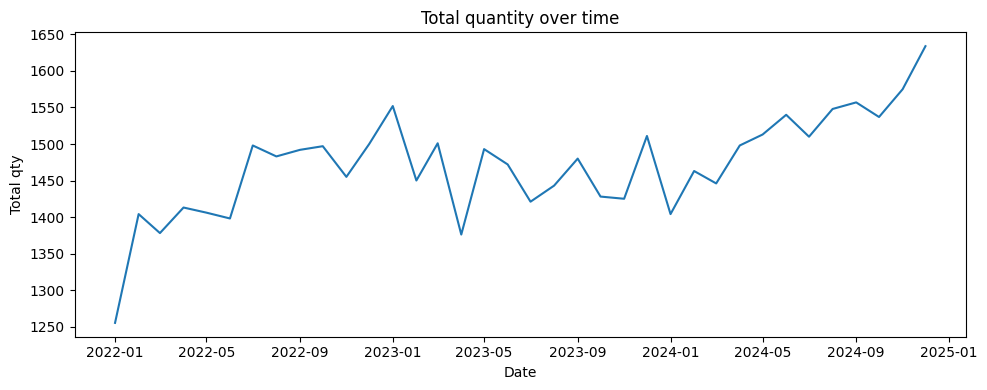

In [36]:
plt.figure(figsize=(10, 4))
plt.plot(overall["date"], overall["qty"])
plt.title("Total quantity over time")
plt.xlabel("Date")
plt.ylabel("Total qty")
plt.tight_layout()
plt.show()

## Demand by family

In [37]:
fam_ts = df.groupby(["date", "family"], as_index=False)["qty"].sum()
fam_pivot = fam_ts.pivot(index="date", columns="family", values="qty").sort_index()
fam_pivot.head()

family,FAM1,FAM2,FAM3,FAM4,FAM5
date,,,,,
2022-01-01,143,228,251,291,342
2022-02-01,181,218,283,341,381
2022-03-01,186,200,290,317,385
2022-04-01,167,218,302,318,408
2022-05-01,172,258,231,342,403


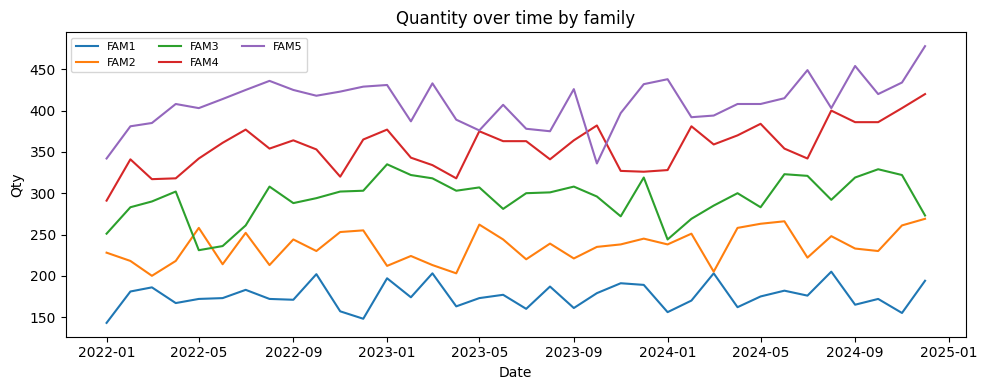

In [38]:
plt.figure(figsize=(10, 4))
for col in fam_pivot.columns:
    plt.plot(fam_pivot.index, fam_pivot[col], label=col)
plt.title("Quantity over time by family")
plt.xlabel("Date")
plt.ylabel("Qty")
plt.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

## Top SKUs by total volume

In [39]:
sku_totals = df.groupby("sku", as_index=False)["qty"].sum().sort_values("qty", ascending=False)
sku_totals.head(10)

,sku,qty
49,SKU5_010,1578
46,SKU5_007,1575
48,SKU5_009,1573
45,SKU5_006,1552
42,SKU5_003,1548
44,SKU5_005,1539
41,SKU5_002,1535
40,SKU5_001,1484
38,SKU4_009,1364
39,SKU4_010,1360


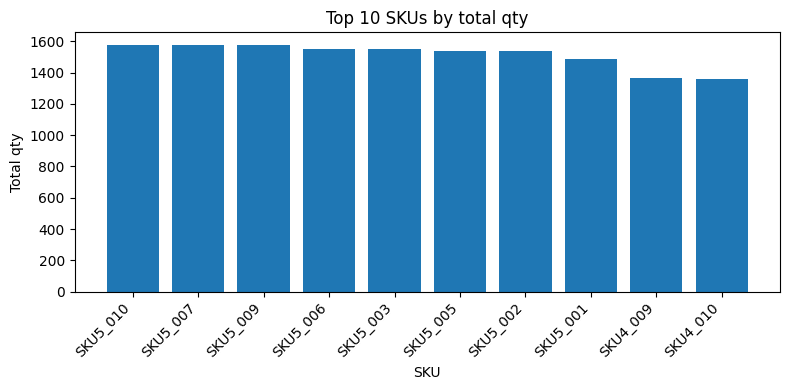

In [40]:
top10 = sku_totals.head(10).set_index("sku")
plt.figure(figsize=(8, 4))
plt.bar(top10.index, top10["qty"])
plt.title("Top 10 SKUs by total qty")
plt.xlabel("SKU")
plt.ylabel("Total qty")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Variability by SKU

In [41]:
sku_stats = df.groupby("sku").agg(
    total_qty=("qty", "sum"),
    mean_qty=("qty", "mean"),
    std_qty=("qty", "std"),
    min_qty=("qty", "min"),
    max_qty=("qty", "max")
).reset_index()
sku_stats["cv"] = sku_stats["std_qty"] / sku_stats["mean_qty"]
sku_stats.sort_values("cv", ascending=False).head(10)

,sku,total_qty,mean_qty,std_qty,min_qty,max_qty,cv
17,SKU2_008,617,17.138889,12.312950,0,40,0.718422
7,SKU1_008,472,13.111111,9.306765,0,30,0.709838
3,SKU1_004,473,13.138889,8.777090,0,30,0.668024
23,SKU3_004,790,21.944444,14.573840,0,43,0.664124
47,SKU5_008,1164,32.333333,19.224984,0,51,0.594587
33,SKU4_004,1039,28.861111,16.064429,0,48,0.556612
13,SKU2_004,712,19.777778,10.663988,0,38,0.539190
43,SKU5_004,1201,33.361111,17.811959,0,54,0.533914
27,SKU3_008,933,25.916667,12.203922,0,41,0.470891
37,SKU4_008,1137,31.583333,14.732617,0,50,0.466468


## Seasonality hint (aggregate)

In [42]:
month_profile = df.groupby("month", as_index=False)["qty"].sum().sort_values("month")
month_profile

,month,qty
0,1,4211
1,2,4317
2,3,4325
3,4,4287
4,5,4412
5,6,4410
6,7,4429
7,8,4474
8,9,4529
9,10,4462


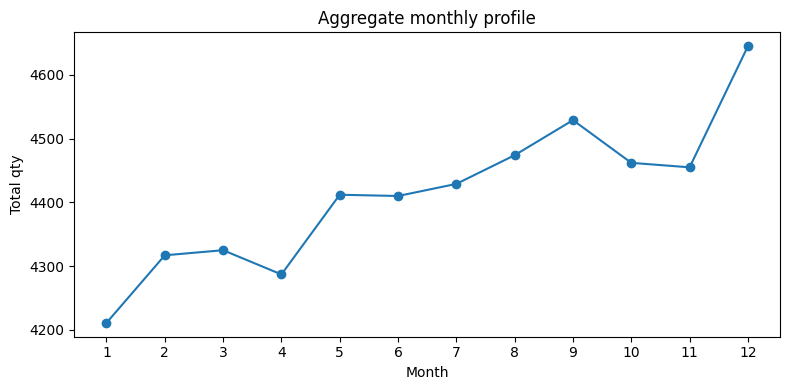

In [43]:
plt.figure(figsize=(8, 4))
plt.plot(month_profile["month"], month_profile["qty"], marker="o")
plt.title("Aggregate monthly profile")
plt.xlabel("Month")
plt.ylabel("Total qty")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

## Unit cost checks

In [44]:
df[["unit_cost"]].describe()

,unit_cost
count,1800.000000
mean,6.746400
std,0.554673
min,5.380000
25%,6.440000
50%,6.775000
75%,7.090000
max,7.770000


In [45]:
cost_sku = df.groupby("sku")["unit_cost"].nunique().sort_values(ascending=False)
cost_sku.head(10)

sku
SKU1_001    1
SKU4_008    1
SKU3_008    1
SKU3_009    1
SKU3_010    1
SKU4_001    1
SKU4_002    1
SKU4_003    1
SKU4_004    1
SKU4_005    1
Name: unit_cost, dtype: int64

## Revenue proxy (qty * unit_cost)

In [46]:
df["value"] = df["qty"] * df["unit_cost"]
val_family = df.groupby("family", as_index=False)["value"].sum().sort_values("value", ascending=False)
val_family

,family,value
4,FAM5,103743.60
3,FAM4,87292.01
2,FAM3,67319.67
1,FAM2,58145.84
0,FAM1,42524.28


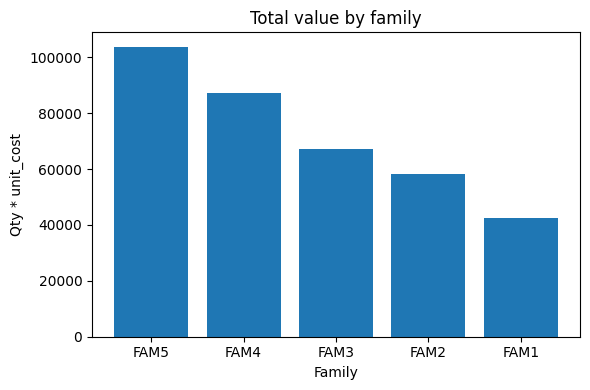

In [47]:
plt.figure(figsize=(6, 4))
plt.bar(val_family["family"], val_family["value"])
plt.title("Total value by family")
plt.xlabel("Family")
plt.ylabel("Qty * unit_cost")
plt.tight_layout()
plt.show()

---


In [48]:
expected_months = df["date"].nunique()
sku_coverage = df.groupby("sku")["date"].nunique().reset_index(name="months")
sku_coverage["complete"] = sku_coverage["months"] == expected_months
sku_coverage["complete"].value_counts(), sku_coverage.head()

(complete
 True    50
 Name: count, dtype: int64,
         sku  months  complete
 0  SKU1_001      36      True
 1  SKU1_002      36      True
 2  SKU1_003      36      True
 3  SKU1_004      36      True
 4  SKU1_005      36      True)

In [49]:
incomplete = sku_coverage.loc[~sku_coverage["complete"], "sku"].tolist()
incomplete[:10]

[]